# 04½ — Probability & Bayes' Theorem

> Probability is the language ML speaks. A logistic regression (notebook 04)
> outputs a *probability* of a class; softmax (notebooks 09, 14) is a probability
> *distribution*; every hypothesis test in notebook 05 derives from a probability
> distribution; a VAE (notebook 18) *samples* from one. If you've ever been fuzzy
> on what a "prior" is, or why a 99%-accurate medical test leaves you only
> 50%-likely to be sick, this notebook is for you. We build the three foundations —
> **conditional probability**, **Bayes' theorem**, and **random variables /
> distributions** — with plots and real data, then connect each one to where it
> reappears later in the handbook.

## What you'll be able to do after this notebook

1. Distinguish the **three meanings of probability** (classical, frequentist,
 Bayesian) and stop confusing them (§0).
2. Compute **joint, marginal, and conditional** probabilities from a contingency
 table, and explain the difference with a picture.
3. State and **apply Bayes' theorem** — and survive the disease-screening paradox
 (a 99%-accurate test → only ~50% chance you're actually sick).
4. Explain **independence vs uncorrelatedness** — and why correlation (§2.1) is
 the *weaker* property.
5. Recognise the **core distributions** (Bernoulli, Binomial, Poisson, Uniform,
 Normal, Exponential, Log-normal) and when each appears in ML.
6. **See the Central Limit Theorem happen** — and understand why t-tests and ANOVA
 (notebook 05) rely on it.
7. Tie it together: how a **Naive Bayes classifier** uses all of the above.

## The process

```mermaid
flowchart LR
 A["joint P(A,B)"] --> B["marginal P(A)"]
 B --> C["conditional P(A|B)"]
 C --> D{Bayes theorem}
 D --> E["update belief with evidence"]
 E --> F["posterior P(H|D)"]
 C --> G["random variables<br/>+ distributions"]
 G --> H["CLT -> normal<br/>-> t-tests / ANOVA"]
 F --> I["naive Bayes<br/>classifier"]
 style D fill:#fde,stroke:#c44e52
 style F fill:#dfd,stroke:#55a868
 style H fill:#dde,stroke:#4c72b0
```

Bayes' theorem (red) is the keystone: it turns a conditional you *can* measure
($P(	ext{test+}|	ext{sick})$) into the one you *actually want*
($P(	ext{sick}|	ext{test+})$).

## 1. The three meanings of "probability"

Before any math, disambiguate — because "probability" means three different things
in three different rooms (§0):

| Meaning | What "P=0.7" claims | Where you meet it |
|---|---|---|
| **Classical** | 7 of 10 equally-likely outcomes | dice, cards, textbook counting |
| **Frequentist** | in 70% of infinitely many repeats, it happens | A/B tests (notebook 05), coin flips |
| **Bayesian** | my degree of belief, given what I know | spam filters, weather, "is this user a bot?" |

A frequentist says *"the probability the coin is fair is meaningless — it either is
or isn't; only repeated flips have probabilities."* A Bayesian says *"given the
flips I've seen, I'm 90% sure the coin is fair."* Both are internally consistent;
they disagree about what probability *is*. Most ML (softmax, logistic regression,
Naive Bayes) is quietly **Bayesian** — it treats model outputs as degrees of belief.
Hypothesis testing (notebook 05) is **frequentist**. Knowing which room you're in
prevents a lot of confusion.

## 2. Joint, marginal, and conditional — the three probabilities

Everything in probability is one of three quantities, and they're easiest to see in
a **contingency table** (a count of how often each combination occurs):

- **Joint** $P(A, B)$ — the probability *both* happen. The body of the table.
- **Marginal** $P(A)$ — the probability $A$ happens, ignoring $B$. The row/column
 sums ("marginalised over" $B$).
- **Conditional** $P(A \mid B)$ — the probability $A$ happens, **given** $B$
 happened. $P(A \mid B) = P(A,B) / P(B)$.

Let's compute all three on the CEO dataset: does `Stock_Market` (Yes/No) depend on
`Sector` (Banking/Hospitality/Health Care)?

In [1]:
from setup import *

ceo = pd.read_csv("data/ceo_data.csv")

# A 2x3 contingency table: rows = Stock_Market, cols = Sector.
ct = pd.crosstab(ceo["Stock_Market"], ceo["Sector"])
print("counts (joint, as frequencies):")
print(ct)
print(f"\ntotal observations: {ct.values.sum()}")

counts (joint, as frequencies):
Sector        Banking  Health Care  Hospitality
Stock_Market                                   
No                 10            6            2
Yes                10           14           18

total observations: 60


In [2]:
# Turn counts into the three probability objects.
joint = ct / ct.values.sum() # P(Stock_Market, Sector)
p_sector = joint.sum(axis=0) # P(Sector) -- marginal over Stock_Market
p_stock = joint.sum(axis=1) # P(Stock_Market)
conditional = joint.div(p_sector, axis=1) # P(Stock_Market | Sector) = joint / P(Sector)

print("P(Stock_Market | Sector) — the conditional: how the Yes-rate varies by sector")
print(conditional.round(3))
print(f"\nP(Stock_Market=Yes) overall (marginal): {p_stock['Yes']:.3f}")

P(Stock_Market | Sector) — the conditional: how the Yes-rate varies by sector
Sector        Banking  Health Care  Hospitality
Stock_Market                                   
No                0.5          0.3          0.1
Yes               0.5          0.7          0.9

P(Stock_Market=Yes) overall (marginal): 0.700


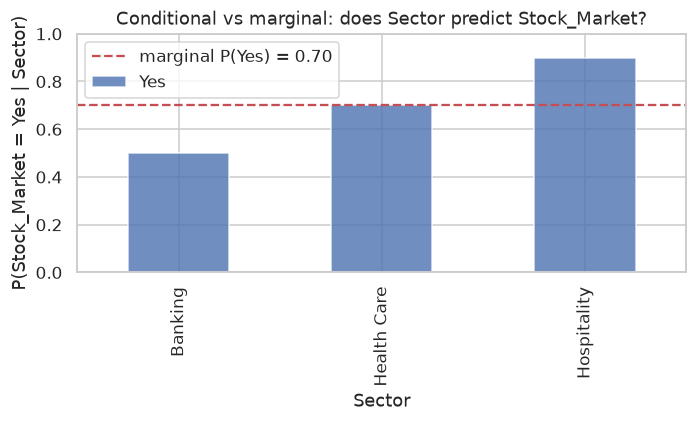

If the bars were all equal to the dashed line, Sector and Stock_Market would be INDEPENDENT. They're not quite — Health Care has a different Yes-rate.


In [3]:
# Plot it: P(Stock_Market=Yes | Sector) vs the marginal. If they differ, the
# variables are DEPENDENT (sector tells you something about stock-market status).
yes_given_sector = conditional.loc["Yes"]
fig, ax = plt.subplots(figsize=(6.5, 4))
yes_given_sector.plot(kind="bar", ax=ax, color="#4c72b0", alpha=0.8)
ax.axhline(p_stock["Yes"], color="#c44e52", ls="--",
 label=f"marginal P(Yes) = {p_stock['Yes']:.2f}")
ax.set_ylabel("P(Stock_Market = Yes | Sector)")
ax.set_title("Conditional vs marginal: does Sector predict Stock_Market?")
ax.set_ylim(0, 1)
ax.legend(); plt.tight_layout(); plt.show()
print("If the bars were all equal to the dashed line, Sector and Stock_Market "
 "would be INDEPENDENT. They're not quite — Health Care has a different Yes-rate.")

The bars are the conditional probabilities $P(\text{Yes} \mid \text{Sector})$; the
dashed line is the marginal $P(\text{Yes})$. If the variables were **independent**,
every bar would exactly match the line. Where they diverge, the sector carries
information about stock-market status.

> **The chain of identities (§4.1).** Marginal = sum of joints:
> $P(A) = \sum_B P(A,B)$. Conditional = joint normalised:
> $P(A|B) = P(A,B)/P(B)$. And the whole of Bayes' theorem (next section) is just
> rearranging that last equation.

## 3. Independence vs uncorrelatedness (don't confuse them)

Two variables are **independent** if knowing one tells you *nothing* about the
other: $P(A|B) = P(A)$ for all $B$. Two variables are **uncorrelated** if their
**linear** relationship is zero (§2.1, Pearson $r = 0$). Independence is far
stronger:

$$\text{independent} \;\Longrightarrow\; \text{uncorrelated}, \quad\text{but NOT vice versa.}$$

A classic trap: $X \sim \mathcal{N}(0,1)$ and $Y = X^2$. They are **perfectly
dependent** (knowing $X$ tells you $Y$ exactly) but their Pearson correlation is
**zero** (the relationship is nonlinear). Let's show it.

corr(X, X^2) = -0.026 <- essentially ZERO, yet Y is fully determined by X


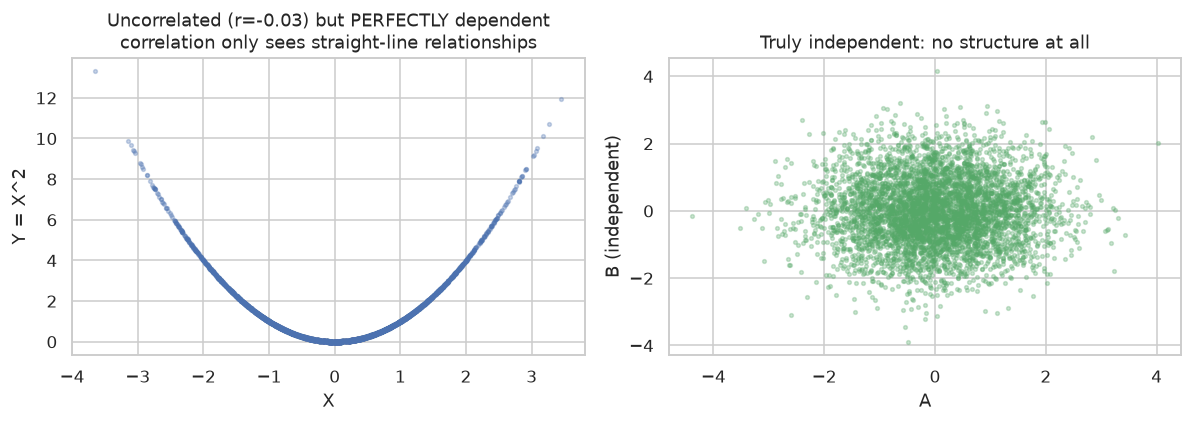


Lesson: correlation=0 does NOT mean independent. Independence is the stronger claim. ML models that capture nonlinearity (trees, NNs) find relationships that correlation (and linear regression) miss.


In [4]:
rng = np.random.default_rng(42)
X = rng.normal(0, 1, 5000)
Y = X ** 2 # perfectly dependent on X
r = np.corrcoef(X, Y)[0, 1]
print(f"corr(X, X^2) = {r:.3f} <- essentially ZERO, yet Y is fully determined by X")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(X, Y, s=6, alpha=0.3, color="#4c72b0")
axes[0].set_xlabel("X"); axes[0].set_ylabel("Y = X^2")
axes[0].set_title(f"Uncorrelated (r={r:.2f}) but PERFECTLY dependent\n"
 f"correlation only sees straight-line relationships")
# contrast: independent
A = rng.normal(0, 1, 5000); B = rng.normal(0, 1, 5000)
axes[1].scatter(A, B, s=6, alpha=0.3, color="#55a868")
axes[1].set_xlabel("A"); axes[1].set_ylabel("B (independent)")
axes[1].set_title("Truly independent: no structure at all")
plt.tight_layout(); plt.show()
print("\nLesson: correlation=0 does NOT mean independent. Independence is the "
 "stronger claim. ML models that capture nonlinearity (trees, NNs) find "
 "relationships that correlation (and linear regression) miss.")

## 4. Bayes' theorem — the centrepiece 

Bayes' theorem is one line of algebra that flips a conditional:

$$\boxed{\;P(H \mid D) = \frac{P(D \mid H)\, P(H)}{P(D)}\;}$$

Read it as: **posterior = likelihood × prior ÷ evidence**.

- $P(H)$ — the **prior**: how likely the hypothesis was *before* seeing data.
- $P(D|H)$ — the **likelihood**: how likely the data is *if* the hypothesis is true.
- $P(H|D)$ — the **posterior**: how likely the hypothesis is *after* seeing data.
- $P(D)$ — the **evidence**: a normalising constant (often expanded as
 $P(D|H)P(H) + P(D|\neg H)P(\neg H)$).

This matters because we usually **can measure the likelihood** (test accuracy:
$P(\text{test+}|\text{sick})$) but we **want the posterior** ($P(\text{sick}|\text{test+})$).
Bayes flips one into the other — and the flip is *not* intuitive, which is why
base-rate neglect is the most common probability error.

### 4.1 The disease-screening paradox (the intuition pump)

A disease affects **1%** of the population. You take a test that is **99%
accurate** (meaning: if you're sick it's positive 99% of the time, and if you're
healthy it's negative 99% of the time). You test **positive**. What's the
probability you're actually sick?

Most people say 99%. The real answer is about **50%**. Here's Bayes:

$$P(\text{sick}|+) = \frac{P(+|\text{sick})\,P(\text{sick})}{P(+|\text{sick})P(\text{sick}) + P(+|\text{healthy})P(\text{healthy})}$$

In [5]:
def posterior_sick(prior_sick, sensitivity, specificity):
 # P(sick | positive) by Bayes. specificity = P(test- | healthy).
 p_pos_sick = sensitivity
 p_pos_healthy = 1 - specificity
 prior_healthy = 1 - prior_sick
 evidence = p_pos_sick * prior_sick + p_pos_healthy * prior_healthy
 return (p_pos_sick * prior_sick) / evidence

prior = 0.01 # 1% prevalence
sens = 0.99 # P(+ | sick)
spec = 0.99 # P(- | healthy)
post = posterior_sick(prior, sens, spec)
print(f"Disease prevalence {prior*100:.0f}%, test {sens*100:.0f}% sensitive / {spec*100:.0f}% specific")
print(f"P(sick | test+) = {post:.3f} <- NOT 0.99!")
print("\nThe denominator is dominated by the many healthy people who get false "
 "positives. This is base-rate neglect: people ignore the prior (prevalence).")

Disease prevalence 1%, test 99% sensitive / 99% specific
P(sick | test+) = 0.500 <- NOT 0.99!

The denominator is dominated by the many healthy people who get false positives. This is base-rate neglect: people ignore the prior (prevalence).


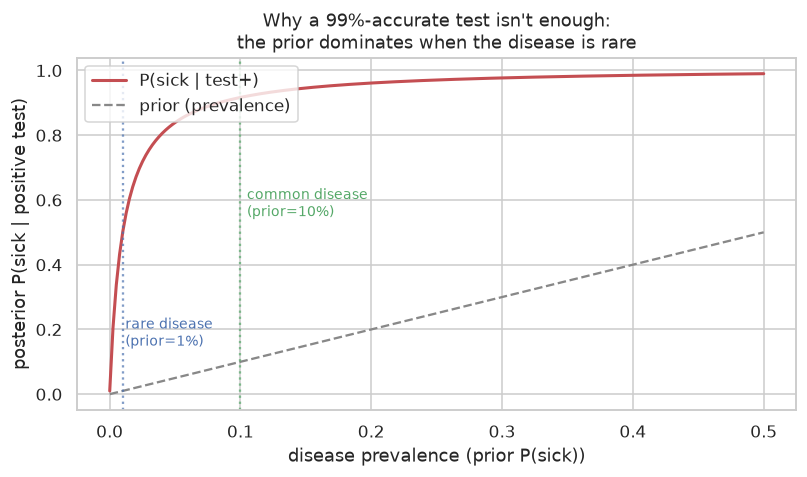

In [6]:
# Sweep the prevalence (prior) and watch the posterior change.
prevalences = np.linspace(0.0001, 0.5, 200)
posteriors = [posterior_sick(p, 0.99, 0.99) for p in prevalences]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(prevalences, posteriors, color="#c44e52", lw=2, label="P(sick | test+)")
ax.plot(prevalences, prevalences, color="#888", ls="--", label="prior (prevalence)")
ax.axvline(0.01, color="#4c72b0", ls=":", alpha=0.7)
ax.text(0.012, 0.15, "rare disease\n(prior=1%)", color="#4c72b0", fontsize=9)
ax.axvline(0.10, color="#55a868", ls=":", alpha=0.7)
ax.text(0.105, 0.55, "common disease\n(prior=10%)", color="#55a868", fontsize=9)
ax.set_xlabel("disease prevalence (prior P(sick))")
ax.set_ylabel("posterior P(sick | positive test)")
ax.set_title("Why a 99%-accurate test isn't enough:\nthe prior dominates when the disease is rare")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

**Reading the curve:** when the disease is rare (prior ≈ 1%), even a 99%-accurate
test yields a posterior of only ~50% — because *most* positive results are false
positives from the huge healthy population. As prevalence rises, the same test
becomes far more informative. **The prior matters as much as the evidence.** This
is why screening tests for rare diseases (cancer in young people, rare genetic
conditions) generate far more false alarms than true positives — and why
confirmatory testing matters.

> **Where this reappears in ML:**
> - **Spam filtering (Naive Bayes)** — §5 below uses exactly this flip.
> - **Logistic regression (notebook 04)** — outputs $P(y=1|x)$, a posterior under a
> particular (frequentist-flavoured) model.
> - **Precision/recall trade-off (notebook 05)** — precision *is* the posterior
> $P(\text{relevant}|\text{retrieved})$; low prevalence kills precision for the
> same reason the test above does.
> - **The prosecutor's fallacy** — confusing $P(\text{evidence}|\text{innocent})$
> with $P(\text{innocent}|\text{evidence})$. Same error, courtroom edition.

## 5. Naive Bayes — probability's gift to classification

Bayes' theorem classifies: given features $x$, predict the class $y$ that maximises
the posterior:

$$\hat{y} = \arg\max_y P(y \mid x) = \arg\max_y P(x \mid y)\, P(y)$$

The "naive" part: assume features are **conditionally independent** given the class,
so $P(x_1, \dots, x_n \mid y) \approx \prod_i P(x_i \mid y)$. The assumption is
almost always *false* (features correlate), yet the classifier works remarkably
well — it's the workhorse of spam filters, sentiment baselines, and medical
diagnosis scoring. scikit-learn gives it to us in one line.

In [7]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

# Predict Stock_Market from the CEO categorical features using Naive Bayes.
y = (ceo["Stock_Market"] == "Yes").astype(int)
feat = ["Sector", "CEO_Gender", "Size", "Sec_Rating", "CEO_Sec_Exp"]
X = ceo[feat].astype(str)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_enc = enc.fit_transform(X)

nb = CategoricalNB(alpha=1.0) # alpha=1 is Laplace smoothing (a prior)
scores = cross_val_score(nb, X_enc, y, cv=5, scoring="accuracy")
baseline = 1 - y.mean() # always predict the majority class
print(f"Naive Bayes accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"baseline (majority class): {baseline:.3f}")
print("\nNB squeezes signal from 60 rows of categorical data — and its "
 "'probability' outputs are genuine posteriors, the same Bayes flip as §4.")

Naive Bayes accuracy: 0.583 ± 0.139
baseline (majority class): 0.300

NB squeezes signal from 60 rows of categorical data — and its 'probability' outputs are genuine posteriors, the same Bayes flip as §4.


On this tiny dataset Naive Bayes barely beats the baseline (60 rows can't carry
much), but the *mechanism* is the point: every prediction is a posterior computed
via Bayes' theorem, with the conditional independences doing the heavy lifting.
The `alpha=1` parameter is **Laplace smoothing** — a prior that says "each category
has been seen at least once", which stops zero-probability multiplications. Smoothing
*is* a prior; everything in Naive Bayes is Bayes.

## 6. Random variables & the distributions you'll meet

A **random variable** is a variable whose value comes from a probability
distribution. We distinguish:

- **Discrete** — takes specific values (counts): coin flips, die rolls, number of
 clicks. Described by a **PMF** (probability mass function), $P(X=x)$.
- **Continuous** — takes any value in a range: height, time, weight. Described by
 a **PDF** (probability density function); probability is the *area under the curve*.

Every distribution has two summary numbers: the **expected value** $E[X]$ (the
mean, the centre of mass) and the **variance** $\text{Var}(X)$ (the spread). Here
are the six you'll keep meeting in ML (§1.4 has the formulas):

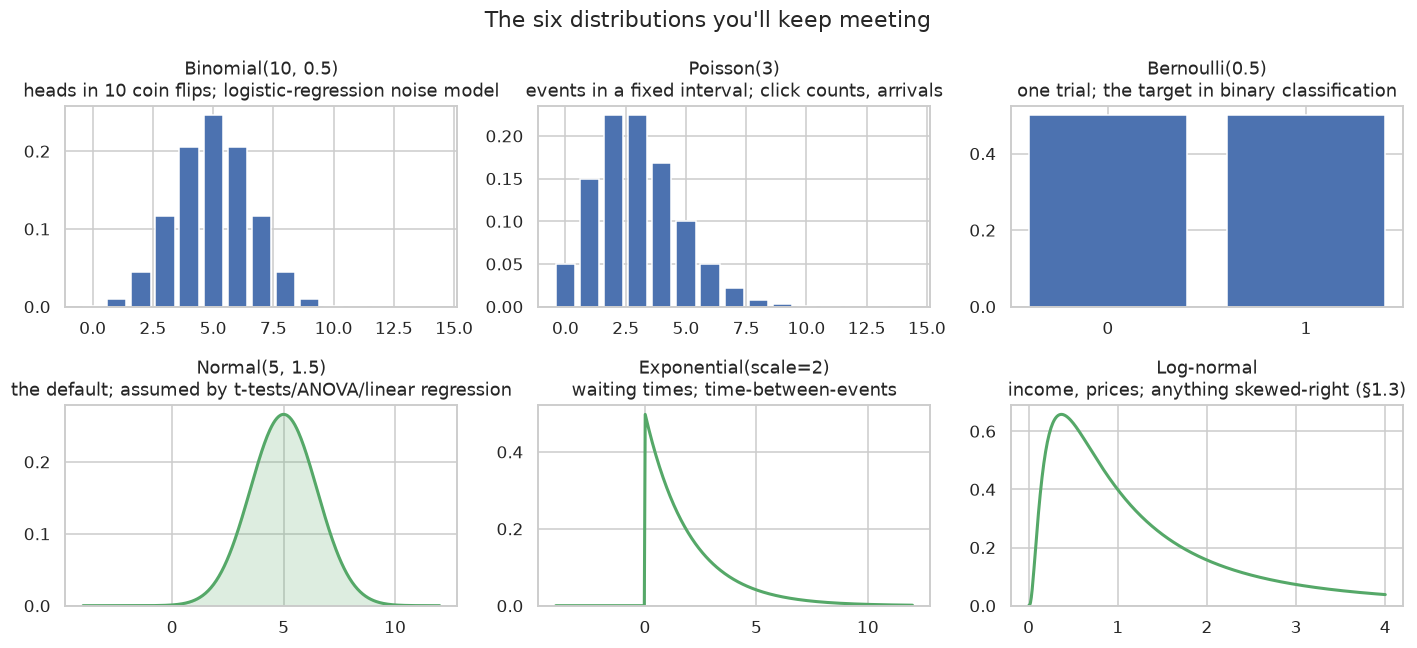

In [8]:
from scipy import stats as ss

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
x = np.linspace(-4, 12, 400)

# Discrete
xs = np.arange(0, 15)
axes[0,0].bar(xs, ss.binom.pmf(xs, n=10, p=0.5), color="#4c72b0")
axes[0,0].set_title("Binomial(10, 0.5)\nheads in 10 coin flips; logistic-regression noise model")
axes[0,1].bar(xs, ss.poisson.pmf(xs, mu=3), color="#4c72b0")
axes[0,1].set_title("Poisson(3)\nevents in a fixed interval; click counts, arrivals")
axes[0,2].bar([0,1], [0.5,0.5], color="#4c72b0"); axes[0,2].set_xticks([0,1])
axes[0,2].set_title("Bernoulli(0.5)\none trial; the target in binary classification")

# Continuous
axes[1,0].plot(x, ss.norm.pdf(x, 5, 1.5), color="#55a868", lw=2)
axes[1,0].set_title("Normal(5, 1.5)\nthe default; assumed by t-tests/ANOVA/linear regression")
axes[1,0].fill_between(x, ss.norm.pdf(x, 5, 1.5), alpha=0.2, color="#55a868")
axes[1,1].plot(x, ss.expon.pdf(x, scale=2), color="#55a868", lw=2)
axes[1,1].set_title("Exponential(scale=2)\nwaiting times; time-between-events")
xs2 = np.linspace(0, 4, 400)
axes[1,2].plot(xs2, ss.lognorm.pdf(xs2, 1), color="#55a868", lw=2)
axes[1,2].set_title("Log-normal\nincome, prices; anything skewed-right (§1.3)")
for ax in axes.flat: ax.set_ylim(bottom=0)
plt.suptitle("The six distributions you'll keep meeting"); plt.tight_layout(); plt.show()

Two distributions dominate ML practice:

- **Normal (Gaussian)** — the default assumption for *everything*: linear
 regression residuals, t-test/ANOVA sampling distributions, random-weight
 initialisation in neural nets (notebook 15). The Central Limit Theorem (next
 section) is *why* it's everywhere.
- **Bernoulli** — a single yes/no trial. The target of every binary classification
 problem. Logistic regression (notebook 04) models $P(y=1)$ assuming $y$ is
 Bernoulli.

> **Expected value & variance (§1.1–§1.2).** $E[X]$ is the long-run average;
 $\text{Var}(X) = E[(X - E[X])^2]$ is the average squared deviation. These are the
 same mean and variance you've been computing in pandas since notebook 01 — just
 now defined on a *distribution* rather than a sample.

## 7. The Central Limit Theorem, shown not stated

The **Central Limit Theorem (CLT)** says: if you take many independent samples from
*almost any* distribution and average them, those averages are approximately
**Normally distributed** — no matter how non-normal the original distribution was.
This is the single most important theorem in statistics, and the reason the Normal
distribution is everywhere. It's *why* t-tests, ANOVA (notebook 05 §B.6), and
linear-regression confidence intervals all assume normality: they're applied to
*sample means or sums*, which the CLT guarantees are near-normal.

Don't take my word for it — let's draw it.

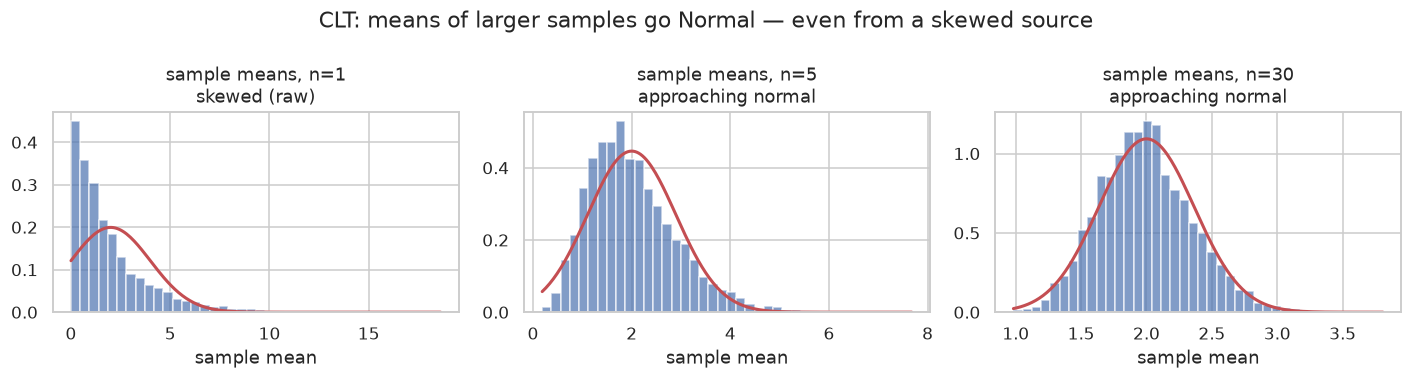

population is Exponential (skewed). By n=30 the sample means are a clean bell curve -> this is WHY t-tests/ANOVA assume normality of the MEAN.


In [9]:
# Start from a strongly SKEWED distribution (exponential), not normal.
rng = np.random.default_rng(7)
pop = ss.expon(scale=2)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
# sample sizes to try: 1 (just the population), 5, 30
for ax, n in zip(axes, [1, 5, 30]):
 # draw 5000 samples of size n, take each sample's mean
 means = pop.rvs(size=(5000, n), random_state=rng).mean(axis=1)
 ax.hist(means, bins=40, density=True, color="#4c72b0", alpha=0.7)
 # overlay the normal the CLT predicts: mean=pop mean, sd=pop sd/sqrt(n)
 sd = pop.std() / np.sqrt(n)
 grid = np.linspace(means.min(), means.max(), 200)
 ax.plot(grid, ss.norm.pdf(grid, pop.mean(), sd), color="#c44e52", lw=2)
 ax.set_title(f"sample means, n={n}\n{'skewed (raw)' if n==1 else 'approaching normal'}")
 ax.set_xlabel("sample mean")
plt.suptitle("CLT: means of larger samples go Normal — even from a skewed source")
plt.tight_layout(); plt.show()
print(f"population is Exponential (skewed). By n=30 the sample means are a clean "
 f"bell curve -> this is WHY t-tests/ANOVA assume normality of the MEAN.")

Watch the sample means converge to a bell curve as `n` grows — even though the
source distribution (exponential) is nothing like normal. By `n=30` the
approximation is excellent. This is the justification for:

- **t-tests / ANOVA (notebook 05)** — they assume the *sample mean* is normal,
 which the CLT guarantees for reasonable `n`, regardless of the population's shape.
- **Regression confidence intervals (notebook 04)** — they rest on the coefficient
 estimates being approximately normal.
- **Why 30 is a magic number** — `n≥30` is the textbook rule of thumb for "CLT has
 kicked in". It's not a cliff, just a safe zone for most source distributions.

> **The honest caveat.** The CLT applies to *means and sums*, not to the raw data.
 A single draw from a skewed distribution is still skewed. The normality
 assumption in a t-test is about the *sampling distribution of the mean*, which
 the CLT handles — not about your raw measurements being bell-shaped.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Base-rate neglect (§4).** The most common probability error. A 99%-accurate
 test for a rare disease gives ~50% posterior, not 99%. Always fold in the prior
 ($P(H)$); it matters as much as the likelihood.
2. **Confusing $P(A|B)$ with $P(B|A)$ (§4) — the prosecutor's fallacy.** "The
 probability of the DNA match given innocent is 1-in-a-million" does **not** mean
 "the probability of innocent given the match is 1-in-a-million". Bayes flips one
 into the other; they are not equal.
3. **Treating uncorrelated as independent (§3).** $r=0$ only rules out *linear*
 dependence. $Y=X^2$ is uncorrelated with $X$ but fully determined by it. Linear
 models (notebook 04) miss this; trees/NNs (notebooks 07–09) catch it.
4. **Assuming independence that isn't there.** Naive Bayes (§5) *assumes* features
 are conditionally independent — often false. It works anyway, but know the
 assumption is doing work. The same trap sinks paired-data t-tests treated as
 unpaired (notebook 05 §B.2).
5. **Normality on the wrong thing (§7).** The CLT makes *sample means* normal, not
 raw data. Don't claim your measurements "are normally distributed" from a
 histogram of 20 points — claim the *mean* is approximately normal.
6. **Ignoring the denominator of Bayes (§4).** $P(D)$ includes *both* the
 true-positive and false-positive paths. Skipping the false positives (from the
 large healthy population) is exactly the disease-screening mistake.
7. **Probability vs statistics (§0).** Probability reasons *forward* (model →
 data); statistics reasons *backward* (data → model). ML does both: train
 (backward/infer) then predict (forward/sample). Mixing the direction confuses
 the language.

## Exercises

1. **(§2)** What's $P(\text{Banking} \mid \text{Stock\_Market=Yes})$ on the CEO
 data? How does it compare to $P(\text{Banking})$ (the marginal)? What does the
 gap (or lack of) tell you?
2. **(§4)** If the disease prevalence rises to 10% (and the test stays 99%
 sensitive/specific), what's the new posterior? Why does a small change in prior
 move the posterior so much more than the same change in test accuracy?
3. **(§4)** A spam filter flags 95% of spam and lets 2% of legitimate mail through
 as spam. If 80% of your mail is spam, what's $P(\text{spam} \mid
 \text{flagged})$? What if only 20% is spam — what changes, and why?
4. **(§6)** A website's daily visitors are Poisson(λ=500). What's the expected
 number of visitors? The variance? Sketch why "number of visitors" is Poisson but
 "time spent on site" is not.
5. **(§7)** Draw 1000 samples of size `n=5` and `n=50` from a **Log-normal**
 distribution (very skewed). For which `n` do the sample means look normal? Does
 the rule "n≥30 is safe" hold for this skewed a source?

<details><summary>Answers (click to expand)</summary>

```python
# 1: P(Banking|Yes) = P(Banking,Yes)/P(Yes). Compute from the contingency table.
# Compare to P(Banking) = marginal. If they're close, Sector and Stock_Market
# are nearly independent w.r.t. Banking; a gap means dependence. On 60 rows the
# gap is usually small and noisy -> don't over-interpret.
# 2: posterior rises to ~0.92. The prior and the posterior are on the same scale;
# a 10x change in prevalence (1%->10%) shifts the false-positive/true-positive
# balance dramatically. Test accuracy moving 98%->99% barely budges the
# posterior because the bottleneck is the false-positive *count*, not the rate.
# 3: At 80% spam: P(spam|flagged) = (0.95*0.8)/(0.95*0.8 + 0.02*0.2) ~ 0.995.
# At 20% spam: P(spam|flagged) = (0.95*0.2)/(0.95*0.2 + 0.02*0.8) ~ 0.92.
# Same filter, very different posterior -> the prior (spam proportion) drives
# precision. This is why a filter trained on a spam-heavy inbox produces false
# alarms when moved to a clean inbox.
# 4: E[visitors]=500, Var=500 (mean=variance for Poisson). Visitors are Poisson
# because they're a count of independent arrivals in a fixed window. Time-on-
# site is continuous and right-skewed -> Exponential or Log-normal, not Poisson.
# 5: For Log-normal (very skewed), n=5 sample means still look skewed; n=50 is
# closer to normal but the tail is heavier than for Exponential. The "n>=30"
# rule is a guideline, not a guarantee -> the more skewed/heavy-tailed the
# source, the larger n needs to be for the CLT to bite.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §0
 (probability dictionary collision), §1.1–§1.4 (mean/variance/distributions),
 §2.1 (correlation vs independence), §4 (probability — this notebook adds §4.3,
 §4.4 there).
- **Notebook 04** — logistic regression outputs $P(y=1)$, a posterior.
- **Notebook 05** — every test there assumes a probability distribution; §B.6
 ANOVA relies on the CLT from §7 here.
- **Notebooks 09, 14, 15** — softmax is a probability distribution; Bayesian
 framing of regularisation (L2 = Gaussian prior).
- Lesson 6 (probability: conditional, Bayes, random variables,
 distributions) — this notebook covers that lesson in full.
- Wasserman, *All of Statistics* (2004), Ch. 1–3. McGrayne, *The Theory That Would
 Not Die* (Bayes' history). 3Blue1Brown's Bayes visualisation:
 <https://www.3blue1brown.com/lessons/bayes-theorem>